In [204]:
import pandas as pd
import glob
import os
from extract import delsys_csv_breakdown

initial_data_path = '/Users/clmckeev/Library/CloudStorage/OneDrive-SharedLibraries-IndianaUniversity/[Sec-E] BL-Phys-NDD_EMG - Documents/NDD_EMG/Data/Raw/All'


In [205]:
subject_id = '001'
subject_folder = os.path.join(initial_data_path,subject_id)
(DT, sensor_config, delsys_data) = delsys_csv_breakdown(os.path.join(subject_folder,f"{subject_id}_emg.csv"))
delsys_data.dropna()

KeyboardInterrupt: 

In [ ]:
p_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'*info.csv'))[0])
mat_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'mat*.csv'))[0])
target_data = pd.read_csv(glob.glob(os.path.join(glob.escape(subject_folder),'target*.csv'))[0])


In [ ]:
info = {}
info['Id'] = subject_id
info['Date'] = DT.iloc[0,1]
info['Age'] = p_data.iloc[0]['Age']
info['Race'] = p_data.iloc[0]['Race']
info['Diagnosis'] = p_data.iloc[0]['Diagnosis']
info['Severity'] = p_data.iloc[0]['Severity']
info['Medicated'] = p_data.iloc[0]['Medicated']
info['Family History'] = p_data.iloc[0]['Family History']
info['Brain Injury/Epilepsy'] = p_data.iloc[0]['Brain Injury/Epilepsy']
info['Dominant Hand'] = p_data.iloc[0]['Dom Hand']
info['Hand-eye Coordination'] = p_data.iloc[0]['Hand-eye']
info['History of hobbies requiring hand eye corrdination'] = p_data.iloc[0]['History Hand-eye']
info['Clumsy'] = p_data.iloc[0]['Clumsy']
info['Inhibition of arm movement'] = p_data.iloc[0]['Inhibition']
info['ASD scale'] = p_data.iloc[0]['ASD scale']
info['ADHD scale A'] = p_data.iloc[0]['ADHD scale A']
info['ADHD scale total'] = p_data.iloc[0]['ADHD scale total']
info['Notes'] = p_data.iloc[0]['Notes']

info['Test Length'] = DT.iloc[1,1]


In [ ]:
info['Test Length'] = DT.iloc[1,1]
for measurement in sensor_config.columns:
    info[measurement] = sensor_config.loc[0, measurement]
print(info)

{'Id': '001', 'Date': ' 2/16/2026 12:33:32 PM', 'Age': np.int64(26), 'Race': 'Hispanic', 'Diagnosis': 'NT', 'Severity': np.float64(nan), 'Medicated': 'No', 'Family History': 'ADHD', 'Brain Injury/Epilepsy': 'No', 'Dominant Hand': 'Right', 'Hand-eye Coordination': 'Ok', 'History of hobbies requiring hand eye corrdination': 'Yes', 'Clumsy': 'Yes', 'Inhibition of arm movement': 'No', 'ASD scale': np.int64(24), 'ADHD scale A': np.int64(2), 'ADHD scale total': np.int64(6), 'Notes': np.float64(nan), 'Test Length': ' 335.4345', ' EMG 1 (mV)': ' 1777.7778 Hz', ' EMG 2 (mV)': ' 1777.7778 Hz', ' ACC X (G)': ' 962.963 Hz', ' ACC Y (G)': ' 962.963 Hz', ' ACC Z (G)': ' 962.963 Hz', ' GYRO X (deg/s)': ' 740.7407 Hz', ' GYRO Y (deg/s)': ' 740.7407 Hz', ' GYRO Z (deg/s)': ' 740.7407 Hz', ' EMG 1 (mV).1': ' 1777.7778 Hz', ' EMG 2 (mV).1': ' 1777.7778 Hz', ' ACC X (G).1': ' 962.963 Hz', ' ACC Y (G).1': ' 962.963 Hz', ' ACC Z (G).1': ' 962.963 Hz', ' GYRO X (deg/s).1': ' 740.7407 Hz', ' GYRO Y (deg/s).1'

In [152]:
import re
print(re.sub(r'[^0-9.]', '', info[' EMG 1 (mV)']))

1777.7778


In [194]:
print(data[[' EMG 1 Time Series (s)',
                   ' EMG 1 (mV)',
                   ' EMG 2 (mV)']].dropna())

                                                                                                                                                                                                               EMG 1 Time Series (s)  \
0.000000   -0.008393 0.0      -0.011078 0.0      -0.04541  0.0      0.287598 0.0      0.886231 0.0     -14.72561  0.0     21.006098 0.0     -3.810976 0.0      -0.060761 0.0      -0.041962 0.0      -0.228516                         
0.000562   -0.010407 0.000562 -0.013092 0.001038 -0.036133 0.001038 0.288574 0.001038 0.896484 0.00135 -14.664635 0.00135 20.487804 0.00135 -4.207317 0.000562 -0.079561 0.000562 -0.041962 0.001038 -0.219727                         
0.001125   -0.009064 0.001125 -0.011078 0.002077 -0.038574 0.002077 0.290039 0.002077 0.895019 0.0027  -14.72561  0.0027  20.396341 0.0027  -3.810976 0.001125 -0.090639 0.001125 -0.041962 0.002077 -0.225586                         
0.001687   -0.007385 0.001687 -0.011078 0.003115 -0.04834  0.003115 0.29

In [173]:
EMG_1 = delsys_data[['EMG 1 Time Series (s) 2', 'EMG 1 (mV) 2', 'EMG 2 (mV) 2']]
EMG_1.columns = ['Time', 'EMG1', 'EMG2']
Analog = delsys_data[[ 'Analog_In_1 Time Series (s)','Analog_In_1 (V)']]
Analog.columns = ['Time', 'Analog']
print(EMG_1)

                                                                                                                                                                                                                                                                                            Time  \
NaN        0.0005625 s           0.0005625 s           0.0010384615384615384 s           0.0010384615384615384 s           0.0010384615384615384 s         0.00135 s           0.00135 s          0.00135 s            0.0005625 s           0.0005625 s           0.0010384615384615384 s   NaN   
0.000000   -0.0083925  0         -0.011078   0         -0.0454102              0         0.2875977               0         0.8862305               0       -14.7256098 0       21.0060978 0       -3.8109758 0         -0.0607614  0         -0.0419623  0         -0.2285156                NaN   
0.000562   -0.0104067  0.0005625 -0.0130922  0.0010385 -0.0361328              0.0010385 0.2885742               0.0010385 0

In [167]:
import matplotlib.pyplot as plt
import numpy as np
from extract import butter_bandpass_filter
from scipy.ndimage import gaussian_filter1d


window_ms = 30
window_samples = int(1777 * window_ms / 1000)
window_samples3 = int(1777 * window_ms*3 / 1000)

gauss = gaussian_filter1d(np.abs(EMG_1['EMG1']), window_samples)
filt = butter_bandpass_filter(EMG_1['EMG1'], 20, 450, 1777, order = 4)

ValueError: The length of the input vector x must be greater than padlen, which is 27.

In [127]:
from extract import rms_smoothing

smooth = rms_smoothing(filt, window_samples3)

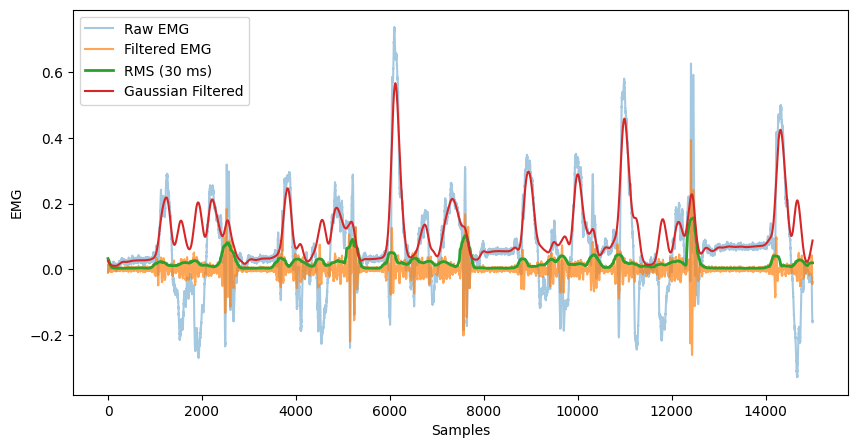

In [120]:

#144000:149000
raw = pd.to_numeric(EMG_1['EMG1'], errors='coerce').iloc[185000:200000].to_numpy()
filtered = np.asarray(filt)[185000:200000]
rms = np.asarray(smooth)[185000:200000]
gauss_filt = np.asarray(gauss)[185000:200000]

plt.figure(figsize=(10,5))
plt.plot(raw, alpha=0.4, label="Raw EMG")
plt.plot(filtered, alpha=0.7, label="Filtered EMG")
plt.plot(rms, linewidth=2, label="RMS (30 ms)")
plt.plot(gauss_filt, label = "Gaussian Filtered")
plt.xlabel("Samples")
plt.ylabel("EMG")
plt.legend()
plt.show()

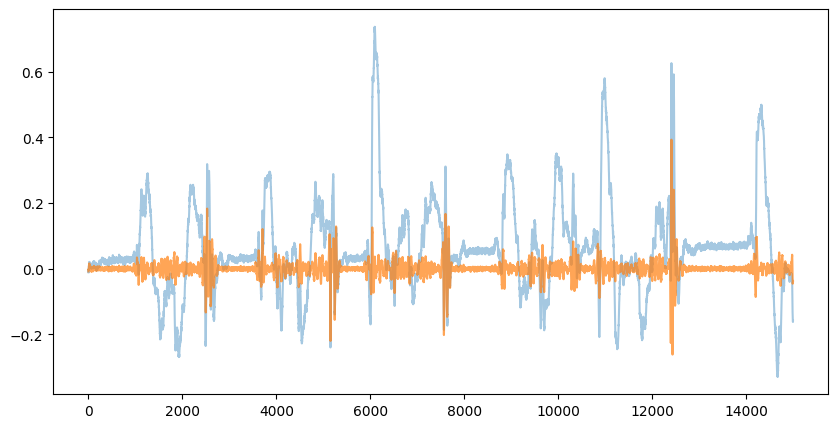

In [121]:
plt.figure(figsize=(10,5))
plt.plot(raw, alpha=0.4, label="Raw EMG")
plt.plot(filtered, alpha=0.7, label="Filtered EMG")

In [165]:
window_ms = 30
window_samples = int(1777 * window_ms / 1000)
window_samples3 = int(1777 * window_ms*3 / 1000)

filt2 = butter_bandpass_filter(EMG_1['EMG2'], 20, 450, 1777, order = 4)
gauss2 = gaussian_filter1d(filt2, window_samples)
smooth2 = rms_smoothing(filt2, window_samples3)

raw2 = pd.to_numeric(EMG_1['EMG2'], errors='coerce').iloc[185000:200000].to_numpy()
filtered2 = np.asarray(filt2)[185000:200000]
rms2 = np.asarray(smooth2)[185000:200000]
gauss_filt2 = np.asarray(gauss2)[185000:200000]

plt.figure(figsize=(10,5))
plt.plot(raw2, alpha=0.4, label="Raw EMG")
plt.plot(filtered2, alpha=0.7, label="Filtered EMG")
plt.plot(rms2, linewidth=2, label="RMS (30 ms)")
plt.plot(gauss_filt2, label = "Gaussian Filtered")
plt.xlabel("Samples")
plt.ylabel("EMG")
plt.legend()
plt.show()

ValueError: The length of the input vector x must be greater than padlen, which is 27.

In [59]:
print(type(EMG_1['EMG1'].iloc[0]))

<class 'numpy.float64'>


In [166]:
print(len(EMG_1['EMG2']))
print(len(filtered2))

0
15000
